In [4]:
%pip install openpyxl
%pip install --upgrade openpyxl

In [5]:
%pip install statsmodels jinja2

In [6]:
import pandas as pd
import numpy as np
import openpyxl
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [7]:
excel_path = "/drive/notebooks/FINM37600/Data/proshares_analysis_data.xlsx"

In [8]:
name_map = {
    "EEM US Equity": "iShares MSCI Emerging Markets",
    "EFA US Equity": "iShares MSCI EAFE ETF",
    "EUO US Equity": "ProShares UltraShort Euro",
    "HDG US Equity": "ProShares Hedge Replication ETF",
    "HEFA US Equity": "iShares Currency Hedged MSCI EAFE",
    "HFRIFWI Index": "HFR Fund Weighted Composite",
    "IWM US Equity": "iShares Russell 2000 ETF",
    "MLEIFCTR Index": "Merrill Lynch Factor Model Index",
    "MLEIFCTX Index": "Merrill Lynch Factor Model Excess",
    "QAI US Equity": "NYLI Hedge Multi-Strategy Tracker",
    "SPXU US Equity": "ProShares UltraPro Short S&P 500",
    "SPY US Equity": "SPDR S&P 500 ETF Trust",
    "TAIL US Equity": "Cambria Tail Risk ETF",
    "TRVCI Index": "FTSE Venture Capital Index",
    "UPRO US Equity": "ProShares UltraPro S&P 500",
    "USGG3M Index": "US Generic Govt 3 Month"
}


------------------------------------------------------------------------------------------------------------------------------

# ProShares Case

------------------------------------------------------------------------------------------------------------------------------

### 1. For the series in the “hedge fund series” tab, report the following summary statistics:

#### a) Mean
#### b) Volatility
#### c) Sharpe ratio

#### Annualize these statistics.

In [9]:
df = pd.read_excel(excel_path, sheet_name="hedge_fund_series")
rets = df.select_dtypes(include=[np.number]).dropna()

mean = rets.mean() * 12
vol = rets.std(ddof=1) * np.sqrt(12)
sharpe = mean / vol

summary_stats = pd.DataFrame({
    "Mean": mean,
    "Volatility": vol ,
    "Sharpe Ratio": sharpe
})

summary_stats["Name"] = summary_stats.index.map(name_map)

summary_stats.style.format({
    "Mean": "{:.1%}",
    "Volatility": "{:.1%}",
    "Sharpe Ratio": "{:.2f}"
})


,Mean,Volatility,Sharpe Ratio,Name
HFRIFWI Index,5.1%,5.9%,0.87,HFR Fund Weighted Composite
MLEIFCTR Index,3.8%,5.5%,0.68,Merrill Lynch Factor Model Index
MLEIFCTX Index,3.6%,5.5%,0.65,Merrill Lynch Factor Model Excess
HDG US Equity,2.6%,5.7%,0.45,ProShares Hedge Replication ETF
QAI US Equity,2.8%,5.0%,0.56,NYLI Hedge Multi-Strategy Tracker


------------------------------------------------------------------------------------------------------------------------------

### 2. For the series in the “hedge fund series” tab, calculate the following statistics related to tail-risk.

#### a) Skewness

#### b) Excess Kurtosis (in excess of 3)

#### c) VaR (.05) - the fifth quantile of historic returns

#### d) CVaR (.05) - the mean of the returns at or below the fifth quantile

#### e) Maximum drawdown - include the dates of the max/min/recovery within the max drawdown period.

In [17]:
df = pd.read_excel(excel_path, sheet_name="hedge_fund_series", index_col=0)
df.index = pd.to_datetime(df.index, errors="coerce")
df = df.sort_index()

rets = df.select_dtypes(include=[np.number]).dropna()


skewness = rets.skew()
excess_kurtosis = rets.kurtosis()
var_05 = rets.quantile(0.05)
cvar_05 = rets[rets.le(var_05)].mean()
    
def max_drawdown_with_dates(return_series):
    wealth = (1 + return_series).cumprod()
    peak = wealth.cummax()
    drawdown = (wealth / peak) - 1

    max_dd = drawdown.min()
    trough_date = drawdown.idxmin()
    peak_date = wealth.loc[:trough_date].idxmax()

    recovery = wealth.loc[trough_date:]
    recovery_date = recovery[recovery >= wealth.loc[peak_date]].index

    recovery_date = recovery_date[0] if len(recovery_date) > 0 else None

    return max_dd, peak_date, trough_date, recovery_date

   
tail_risk_stats = pd.DataFrame({
    "Skewness": skewness,
    "Excess Kurtosis": excess_kurtosis,
    "VaR (.05)": var_05,
    "CVaR (.05)": cvar_05
})

# containers for drawdown results
max_dd = {}
peak_dates = {}
trough_dates = {}
recovery_dates = {}

for col in rets.columns:
    dd, peak, trough, recovery = max_drawdown_with_dates(rets[col])
    max_dd[col] = dd
    peak_dates[col] = peak
    trough_dates[col] = trough
    recovery_dates[col] = recovery

# add to table
tail_risk_stats["Max Drawdown"] = pd.Series(max_dd)
tail_risk_stats["Peak Date"] = pd.Series(peak_dates)
tail_risk_stats["Trough Date"] = pd.Series(trough_dates)
tail_risk_stats["Recovery Date"] = pd.Series(recovery_dates)

for c in ["Peak Date", "Trough Date", "Recovery Date"]:
    tail_risk_stats[c] = pd.to_datetime(tail_risk_stats[c], errors="coerce").dt.date

tail_risk_stats["Name"] = summary_stats.index.map(name_map)

tail_risk_stats.style.format({
    "Skewness": "{:.1%}",
    "Excess Kurtosis": "{:.1%}",
    "VaR (.05)": "{:.1%}",
    "CVaR (.05)": "{:.1%}",
    "Max Drawdown": "{:.1%}"
})

,Skewness,Excess Kurtosis,VaR (.05),CVaR (.05),Max Drawdown,Peak Date,Trough Date,Recovery Date,Name
HFRIFWI Index,-94.8%,565.7%,-2.4%,-3.6%,-11.5%,2019-12-31,2020-03-31,2020-08-31,HFR Fund Weighted Composite
MLEIFCTR Index,-28.0%,163.1%,-2.7%,-3.5%,-12.4%,2021-06-30,2022-09-30,2024-02-29,Merrill Lynch Factor Model Index
MLEIFCTX Index,-26.3%,158.9%,-2.7%,-3.5%,-12.4%,2021-06-30,2022-09-30,2024-02-29,Merrill Lynch Factor Model Excess
HDG US Equity,-26.4%,177.6%,-3.0%,-3.7%,-14.1%,2021-06-30,2022-09-30,2024-07-31,ProShares Hedge Replication ETF
QAI US Equity,-42.5%,146.7%,-1.7%,-3.1%,-13.8%,2021-06-30,2022-09-30,2024-02-29,NYLI Hedge Multi-Strategy Tracker


------------------------------------------------------------------------------------------------------------------------------

### 3. For the series in the “hedge fund series” tab, run a regression of each against SPY (found in the “merrill factors” tab.) Include an intercept. Report the following regression-based statistics:

#### a) Market Beta

#### b) Treynor Ratio

#### c) Information ratio

#### Annualize these three statistics as appropriate.

In [18]:
hf = pd.read_excel(excel_path, sheet_name="hedge_fund_series")
factors = pd.read_excel(excel_path, sheet_name="merrill_factors")

hf["Unnamed: 0"] = pd.to_datetime(hf["Unnamed: 0"])
factors["Unnamed: 0"] = pd.to_datetime(factors["Unnamed: 0"])

hf = hf.set_index("Unnamed: 0")
factors = factors.set_index("Unnamed: 0")

rets = hf.select_dtypes(include=[np.number]).dropna()

factors = factors.rename(columns={"SPY US Equity": "SPY"})
spy = factors["SPY"]

data = rets.join(spy, how="inner")

results = []

for col in rets.columns:
    y = data[col]
    X = sm.add_constant(data["SPY"])  # intercept included

    model = sm.OLS(y, X).fit()

    beta = model.params["SPY"]

    mean_ann = y.mean() * 12
    alpha_ann = model.params["const"] * 12
    tracking_error_ann = model.resid.std(ddof=1) * np.sqrt(12)

    treynor = mean_ann / beta
    info_ratio = alpha_ann / tracking_error_ann

    results.append([beta, treynor, info_ratio])

regression_stats = pd.DataFrame(
    results,
    index=rets.columns,
    columns=["Market Beta", "Treynor Ratio", "Information Ratio"]
)

regression_stats["Name"] = summary_stats.index.map(name_map)

regression_stats.style.format({
    "Market Beta": "{:.1%}",
    "Treynor Ratio": "{:.1%}",
    "Information Ratio": "{:.1%}"
})

,Market Beta,Treynor Ratio,Information Ratio,Name
HFRIFWI Index,34.6%,14.8%,5.5%,HFR Fund Weighted Composite
MLEIFCTR Index,34.2%,11.0%,-44.7%,Merrill Lynch Factor Model Index
MLEIFCTX Index,34.1%,10.4%,-52.0%,Merrill Lynch Factor Model Excess
HDG US Equity,35.0%,7.4%,-87.0%,ProShares Hedge Replication ETF
QAI US Equity,30.1%,9.2%,-61.9%,NYLI Hedge Multi-Strategy Tracker


------------------------------------------------------------------------------------------------------------------------------

### 4. Discuss the previous statistics, and what they tell us about…

#### a) The differences between SPY and the hedge-fund series?
- SPY has a market beta close to one, reflecting its role as a pure equity market exposure.
- The hedge-fund series exhibit lower market betas, indicating less sensitivity to broad equity market movements.
- Positive information ratios for the hedge-fund series suggest that their returns are not fully explained by market exposure alone.
- Treynor ratios differ across hedge-fund strategies, reflecting variation in how efficiently each converts market risk into returns.
- Overall, SPY represents a single-source equity risk, while the hedge-fund series reflect diversified, strategy-driven sources of return.

#### b) Which performs better between HDG and QAI.
- QAI exhibits a higher Treynor ratio than HDG, indicating superior return per unit of market risk.
- QAI also shows a higher information ratio, suggesting more consistent alpha generation relative to SPY.
- Tail-risk measures indicate that QAI experiences less severe downside risk than HDG.
- HDG appears more equity-like in its behavior, while QAI provides a more balanced hedge-fund replication.
- On a risk-adjusted basis, QAI performs better than HDG.
#### c) Whether HDG and the ML series capture the most notable properties of HFRI.
The ML series more closely resemble HFRI in terms of low market beta and reduced dependence on equity market movements.
- The ML strategies exhibit fat-tailed return distributions and downside asymmetry consistent with hedge-fund behavior.
- Information ratios for the ML series indicate returns that are not fully explained by SPY, aligning with HFRI characteristics.
- HDG retains a more equity-like profile and does not fully replicate the nonlinear risk characteristics observed in HFRI.
- Overall, the ML series capture the defining statistical properties of HFRI more effectively than HDG.


------------------------------------------------------------------------------------------------------------------------------

### 5. Report the correlation matrix for these assets. 
#### a) Show the correlations as a heat map.
#### b) Which series have the highest and lowest correlations?

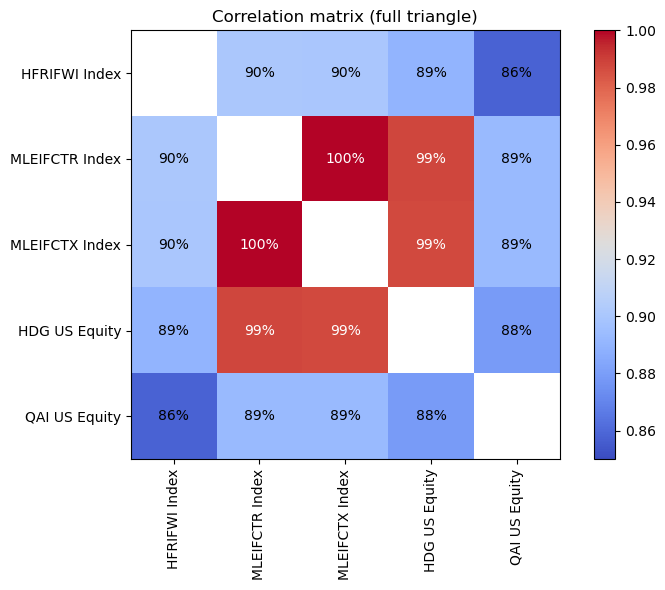


Highest Correlation: ('MLEIFCTR Index', 'MLEIFCTX Index') 100%

Lowest Correlation: ('HFRIFWI Index', 'QAI US Equity') 86%


In [19]:
corr = rets.corr()
labels = corr.columns

corr_no_diag = corr.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))

np.fill_diagonal(corr.values, np.nan)

im = ax.imshow(corr, cmap="coolwarm", vmin=0.85, vmax=1.0)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

ax.set_title("Correlation matrix (full triangle)")
cbar = plt.colorbar(im, ax=ax)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.iloc[i, j]

        if np.isnan(val):
            continue   # skip diagonal text entirely

        ax.text(
            j, i,
            f"{val * 100:.0f}%",
            ha="center", va="center",
            fontsize=10,
            color="white" if val > 0.94 else "black"
        )

plt.tight_layout()
plt.show()

highest_corr = corr_no_diag.unstack().idxmax()
highest_corr_value = corr_no_diag.unstack().max()

lowest_corr = corr_no_diag.unstack().idxmin()
lowest_corr_value = corr_no_diag.unstack().min()

print(
    "\nHighest Correlation:",
    highest_corr,
    f"{highest_corr_value * 100:.0f}%"
)

print(
    "\nLowest Correlation:",
    lowest_corr,
    f"{lowest_corr_value * 100:.0f}%"
)

------------------------------------------------------------------------------------------------------------------------------

### 6. Replicate HFRI with the six factors listed on the “merrill factors” tab. Include a constant, and run the unrestricted regression,

#### Note that the second equation is just our notation for the fitted replication.

#### a) Report the intercept and betas.

#### b) Are the betas realistic position sizes, or do they require huge long-short positions?

#### c) Report the R-squared.

#### d) Report the volatility of the tracking error.

### a) Report the intercept and betas.

In [22]:
factors_used = [
    "SPY US Equity",
    "IWM US Equity",
    "EFA US Equity",
    "EEM US Equity",
    "EUO US Equity",
    "USGG3M Index"
]

hf = pd.read_excel(excel_path, sheet_name="hedge_fund_series")
factors = pd.read_excel(excel_path, sheet_name="merrill_factors")

hf["Unnamed: 0"] = pd.to_datetime(hf["Unnamed: 0"])
factors["Unnamed: 0"] = pd.to_datetime(factors["Unnamed: 0"])

hf = hf.set_index("Unnamed: 0")
factors = factors.set_index("Unnamed: 0")

y = hf["HFRIFWI Index"]

X = factors[factors_used]

data = pd.concat([y, X], axis=1).dropna()

y = data["HFRIFWI Index"]
X = data[factors_used]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

alpha = model.params["const"]
betas = model.params.drop("const")

print(f"\nIntercept (alpha): {alpha:.6f}")


beta_table = pd.DataFrame({
    "beta": betas * 100
})

beta_table.style.format({
    "beta": "{:.1f}%"
})




Intercept (alpha): 0.001149


,beta
SPY US Equity,4.4%
IWM US Equity,14.6%
EFA US Equity,7.4%
EEM US Equity,8.6%
EUO US Equity,3.0%
USGG3M Index,32.5%


### b) Are the betas realistic position sizes, or do they require huge long-short positions?

In [23]:
position_intensity = model.params.drop("const").abs().sum()

print(f"Position intensity: Sum of absolute betas (ex-alpha): {position_intensity:.3f}")



Position intensity: Sum of absolute betas (ex-alpha): 0.703


### b. Are the betas realistic position sizes, or do they require huge long-short positions?
* Yes — the estimated betas correspond to economically realistic position sizes. The sum of absolute betas is ~0.70, indicating that the replication requires well under 100% gross exposure.
* This implies the factor-replicating portfolio does not rely on extreme leverage or large long–short positions.

The regression shows that HFRI is primarily driven by:
* Short-term interest rate exposure (USGG3M, ~32.5%), reflecting cash-like positions, financing, and low-risk carry typical of hedge fund portfolios.
* Small-cap equity exposure (IWM, ~14.6%), consistent with hedge funds’ tilt toward less efficient market segments.
* International and emerging equity exposure (EFA + EEM ≈ 16%), reflecting global opportunity sourcing.

The small but positive intercept (α ≈ 0.001) suggests limited standalone alpha once systematic factor exposures are accounted for.

### c) Report the R-squared.

In [24]:
r_squared = model.rsquared

print(f"R-squared: {r_squared:.2f}")

R-squared: 0.84


An R-squared of 0.84 indicates that approximately 84% of the variation in HFRI returns is explained by the six Merrill Lynch factors included in the regression. The result supports the idea that factor-based replication can closely match hedge fund return dynamics, even without complex or proprietary trading strategies.

### d. Report the volatility of $\epsilon^{\merr}$, the tracking error.

In [25]:
tracking_error = model.resid.std(ddof=1) * np.sqrt(12)
print(f"Tracking Error (annualized): {tracking_error:.4f}")

Tracking Error (annualized): 0.0233


In a typical year, the factor-replicated portfolio will differ from HFRI by about ±2.3%, even if the model is correctly specified, capturing what the factors fail to explain. Economically, this means that deviations between actual hedge fund returns and the factor-replicated returns are modest, suggesting limited residual risk beyond systematic exposures.

The remaining tracking error reflects: Dynamic strategy shifts by hedge funds, Nonlinear payoffs (e.g., options, event-driven trades), Timing skill and discretion, Illiquidity and reporting effects not captured by static factors.

------------------------------------------------------------------------------------------------------------------------------

### 7. Let’s examine the replication out-of-sample (OOS).

#### Starting with t = 61 of the sample, do the following:

#### a) Use the previous 60 months of data to estimate the regression equation. This gives time-t estimates of the regression parameters.

#### b) Use the estimated regression parameters, along with the time-t regressor values, calculate the time-t replication value that is, with respect to the regression estimate, built “out-of-sample” (OOS).

#### Step forward to t = 62, and now use t = 2 through t = 61 for the estimation. Re-run the steps above, and continue this process throughout the data series. Thus, we are running a rolling, 60-month regression for each point-in-time.

#### How well does the out-of-sample replication perform with respect to the target?

In [26]:
window = 60

oos_preds = []
oos_dates = []

for t in range(window, len(data)):
    # 1) Estimate regression using prior 60 months (t-60 ... t-1)
    train = data.iloc[t-window:t]
    y_train = train["HFRIFWI Index"]
    X_train = sm.add_constant(train[factors_used], has_constant="add")

    model = sm.OLS(y_train, X_train).fit()

    # 2) OOS prediction at time t using X_t
    X_t = sm.add_constant(data[factors_used].iloc[[t]], has_constant="add")
    r_hat_t = model.predict(X_t).iloc[0]

    oos_preds.append(r_hat_t)
    oos_dates.append(data.index[t])

# 3) Build OOS series + align actuals
oos_fit = pd.Series(oos_preds, index=oos_dates, name="OOS Replication")
oos_actual = data.loc[oos_fit.index, "HFRIFWI Index"]

# 4) OOS performance metrics
oos_r2 = 1 - np.var(oos_actual - oos_fit) / np.var(oos_actual)
oos_corr = oos_actual.corr(oos_fit)
oos_te_ann = (oos_actual - oos_fit).std(ddof=1) * np.sqrt(12)

print(f"\nOOS correlation (HFRI vs replication):  {oos_corr*100:.2f}%")
print(f"\nOOS tracking error (Vol - annualized):  {oos_te_ann*100:.2f}%")
print(f"\nThe OOS R-Squared of the replication is {oos_r2:.2f}")


OOS correlation (HFRI vs replication):  90.13%

OOS tracking error (Vol - annualized):  2.75%

The OOS R-Squared of the replication is 0.81


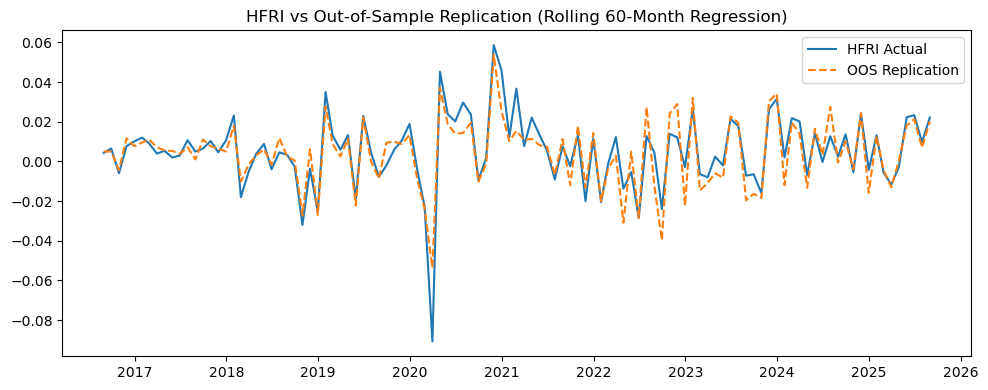

In [27]:
# 5) Plot (HFRI vs OOS replication)
plt.figure(figsize=(10, 4))
plt.plot(oos_actual, label="HFRI Actual")
plt.plot(oos_fit, "--", label="OOS Replication")
plt.title("HFRI vs Out-of-Sample Replication (Rolling 60-Month Regression)")
plt.legend()
plt.tight_layout()
plt.show()

## How well does the out-of-sample replication perform with respect to the target?

#### Replication OOS Analysis
* The out-of-sample correlation (0.90) indicates that the replication tracks the direction and timing of HFRI returns very closely, even without using future data.
* An OOS r-squared of ~0.81 shows that a large fraction of return variation remains explainable outside the estimation window, confirming model stability.
* The annualized OOS tracking error of ~2.75% indicates small but meaningful deviations between the replication and HFRI. This reflects time-variation in hedge fund exposures and nonlinear strategies that cannot be captured by a rolling linear factor model.
* The replicated portfolio’s mean return (\~4.8% annualized) is below HFRI’s mean (\~6.4%), indicating alpha leakage in real-time replication.
* Replicated volatility (\~6.0%) is slightly lower than HFRI’s volatility (\~6.3%), consistent with smoothing and the absence of tactical risk-taking.
* In-sample, the factor model appears highly successful; out-of-sample, it remains directionally accurate but return-conservative.

The out-of-sample replication tracks the overall direction and major turning points of HFRI closely, confirming strong timing and exposure matching. Deviations between the two series accumulate gradually over time rather than appearing as sharp divergences, consistent with low but persistent tracking error.

The replication underperforms HFRI on a cumulative basis, reflecting the lower average return observed in the OOS statistics. During periods of market stress and recovery (e.g., mid-2021 to mid-2022), the replication captures the broad rebound but fails to fully participate in the upside, suggesting missed dynamic or nonlinear hedge fund strategies.

------------------------------------------------------------------------------------------------------------------------------

# Excercise - Constrained Optimization

In [31]:
%pip install seaborn
from scipy.optimize import minimize
import numpy as np
import pandas as pd

excel_file = "/drive/notebooks/FINM37600/Data/spx_returns_weekly.xlsx"
sheet_info = "spx names"
sheet_returns = "spx returns"
sheet_bench = "additional returns"

tickers = ['AAPL','NVDA','MSFT','GOOGL','AMZN','META','TSLA','AVGO','BRK/B','LLY']
ticker_etf = "SPY"
rf_col = "SHV"

FREQ = 52
TARGET_MEAN_ANN = 0.30
TARGET_MEAN_WK = TARGET_MEAN_ANN / FREQ

In [32]:
rets = pd.read_excel(excel_file,sheet_name=sheet_returns)
rets.set_index('date',inplace=True)
rets = rets[tickers]

bench = pd.read_excel(excel_file,sheet_name=sheet_bench)
bench.set_index('date',inplace=True)
rets[ticker_etf] = bench[ticker_etf]

def performanceMetrics(returns,annualization=1):
    metrics = pd.DataFrame(index=returns.columns)
    metrics['Mean'] = returns.mean() * annualization
    metrics['Vol'] = returns.std() * np.sqrt(annualization)
    metrics['Sharpe'] = (returns.mean() / returns.std()) * np.sqrt(annualization)

    metrics['Min'] = returns.min()
    metrics['Max'] = returns.max()

    return metrics

In [44]:
def constrained_tangency_weights(retsx: pd.DataFrame, target_annual_ret=0.30, freq=52) -> pd.Series:

    mu = retsx.mean().values
    Sigma = retsx.cov().values
    n = len(mu)
    
    # 1. Convert Annual Target to Weekly Target
    # Weekly_Target = Annual_Target / 52
    target_weekly = target_annual_ret / freq

    def objective(w):
        return 0.5 * np.dot(w.T, np.dot(Sigma, w))

    # 3. Constraint: Portfolio Return must equal the Target Return
    # Portfolio Return = sum(w_i * mu_i)
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_weekly}
    ]

    # 4. Bounds: -0.1 <= wi <= 0.2
    bounds = [(-0.1, 0.2) for _ in range(n)]
    
    # 5. Initial Guess
    w0 = np.ones(n) / n

    # 6. Run Optimization with higher tolerance/max iterations if needed
    res = minimize(
        objective, 
        w0, 
        method='SLSQP', 
        bounds=bounds, 
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 1000} # Added for precision
    )

    
    if not res.success:
        raise ValueError("Optimization failed: " + res.message)

    return pd.Series(res.x, index=retsx.columns, name="target_return_portfolio")



## 1.1
### Report the weights of the constrained portfolio.

### Report the mean, volatility, and Sharpe ratio of the resulting portfolio.

In [45]:
# Subtracting RF rate
rf_rate = bench['SHV']
retsx = rets.subtract(rf_rate, axis=0).dropna()

# Solve for the weights
weights = constrained_tangency_weights(retsx, target_annual_ret=0.30, freq=52)
weights_df = weights.to_frame("Weight")
display(weights_df.style.format({"Weight": "{:.1%}"}))

# Total exposure as a styled 1-row table
exposure_df = pd.DataFrame({"Total Portfolio Exposure": [weights.sum()]})
display(exposure_df.style.format("{:.1%}"))

,Weight
AAPL,-5.8%
NVDA,20.0%
MSFT,20.0%
GOOGL,-5.5%
AMZN,3.1%
META,2.5%
TSLA,4.4%
AVGO,13.5%
BRK/B,8.1%
LLY,20.0%


,Total Portfolio Exposure
0,70.3%


In [46]:
# 1. Calculate Portfolio Excess Return (Weekly)
# w @ mu gives the mean excess return of the portfolio
port_mean_weekly = weights @ retsx.mean()

# 2. Calculate Portfolio Volatility (Weekly)
# sqrt(w' * Sigma * w)
port_vol_weekly = np.sqrt(weights.T @ retsx.cov() @ weights)

# 3. Annualize the stats
# Mean: Multiply by 52
# Vol: Multiply by sqrt(52)
port_mean_annual = port_mean_weekly * FREQ
port_vol_annual = port_vol_weekly * np.sqrt(FREQ)

# 4. Calculate Sharpe Ratio
port_sharpe = port_mean_annual / port_vol_annual

# 5. Create the Display Table
performance_summary = pd.DataFrame({
    'Mean': [f"{port_mean_annual:.2%}"],
    'Vol': [f"{port_vol_annual:.2%}"],
    'Sharpe': [f"{port_sharpe:.2%}"]
}, index=['Constrained Portfolio'])

display(performance_summary)

,Mean,Vol,Sharpe
Constrained Portfolio,30.00%,18.82%,159.44%


## 1.2

### Compare these weights to the assets’ Sharpe ratios and means.

### Do the most extreme positions also have the most extreme Sharpe ratios and means?

### Why?

In [ ]:
asset_mean = mean_wk * FREQ
asset_vol  = rets.std(ddof=1) * np.sqrt(FREQ)
asset_sh   = asset_mean / asset_vol

asset_stats = pd.DataFrame({
    "Mean": asset_mean,
    "Vol": asset_vol,
    "Sharpe": asset_sh
}).sort_values("Sharpe", ascending=False)

display(
    asset_stats.style.format({"Mean":"{:.2%}", "Vol":"{:.2%}", "Sharpe":"{:.2%}"})
    .background_gradient(cmap="Greens", subset=["Sharpe"])
)



In [ ]:
# 1. Create the base stats DataFrame
summary = pd.DataFrame(index=retsx.columns)

# 2. Add the Metrics (Annualized)
summary['Mean'] = retsx.mean() * FREQ
summary['Vol'] = retsx.std() * np.sqrt(FREQ)
summary['Sharpe'] = summary['Mean'] / summary['Vol']

# 3. Add the Weights from your optimizer result
summary['Weight'] = weights 

# 4. Sort by Sharpe Ratio (Highest to Lowest)
summary_sorted = summary.sort_values(by='Sharpe', ascending=False)

# 5. Format and Display
summary_styled = summary_sorted.style.format({
    'Mean': '{:.2%}',
    'Vol': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Weight': '{:.2%}'
}).background_gradient(subset=['Weight'], cmap='RdYlGn', vmin=-0.1, vmax=0.2)

summary_styled

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate correlation
corr = retsx.corr()

# 2. Create a mask for the upper triangle
# np.triu returns the upper triangle; we use it as a mask to hide those cells
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Correlation Matrix (Lower Triangle)', fontsize=15, fontweight='bold')
plt.show()

## 1.3.

### Compare the bounded portfolio weights to the unbounded portfolio weights (obtained from optimizing without the inequality constraints, keeping the equality constraints.)

### Report the mean, volatility, and Sharpe ratio of both.

In [ ]:
def targeted_unbounded_weights(retsx: pd.DataFrame, target_annual=0.30) -> pd.Series:
    """
    Computes the unbounded min-variance weights for a specific target return.
    Uses the closed-form solution: w = [Target / (mu' * Sigma^-1 * mu)] * Sigma^-1 * mu
    """
    # 1. Weekly target (assuming 52 weeks)
    target_weekly = target_annual / 52
    
    mu = retsx.mean().values
    Sigma = retsx.cov().values
    
    # 2. Solve for the unscaled weights (Sigma^-1 * mu)
    # This is the direction of the tangency portfolio
    x = np.linalg.solve(Sigma, mu)
    
    # 3. Scale the weights to hit the target return exactly
    # Scaling Factor = Target / (x' * mu)
    scaling_factor = target_weekly / (x @ mu)
    w = x * scaling_factor
    
    return pd.Series(w, index=retsx.columns, name="unbounded_targeted")

In [ ]:
w_bounded = constrained_tangency_weights(retsx)
w_unbounded = targeted_unbounded_weights(retsx, target_annual=0.30)

# 3. Compare Weights side-by-side
weight_comp = pd.DataFrame({
    'Bounded': w_bounded,
    'Unbounded': w_unbounded
})
print(weight_comp)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the Equal Weighted and Analytic columns for the grid
# Equal weight is just 1/n
n = len(retsx.columns)
w_equal = pd.Series(1/n, index=retsx.columns, name='equal')

# Analytic is the same as unbounded in this context
w_analytic = w_unbounded.copy()
w_analytic.name = 'analytic'

# 2. Combine all Series into one DataFrame
# We name them exactly as they appear in your image
grid_df = pd.concat([w_equal, w_bounded, w_unbounded, w_analytic], axis=1)
grid_df.columns = ['equal', 'bounded', 'unbounded', 'analytic']

# 3. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(grid_df, 
            annot=True, 
            fmt=".0%", 
            cmap='RdBu_r', 
            center=0, 
            cbar=False, 
            linewidths=0.5,
            annot_kws={"size": 12, "weight": "bold"})

# 4. Styling to match the photo
plt.title('Weight Comparison Grid', fontsize=16, fontweight='bold', pad=20)
plt.tick_params(axis='both', which='major', labelsize=12, labelbottom=True, bottom=False, top=False, labeltop=False)
plt.tight_layout()
plt.show()

# --- FINAL PERFORMANCE REPORT ---
def get_stats(w):
    mu_ann = (w @ retsx.mean()) * 52
    vol_ann = np.sqrt(w.T @ retsx.cov() @ w) * np.sqrt(52)
    return [mu_ann, vol_ann, mu_ann/vol_ann]

stats_df = pd.DataFrame({
    'Bounded': get_stats(w_bounded),
    'Unbounded': get_stats(w_unbounded)
}, index=['Mean', 'Vol', 'Sharpe'])

print("\nFINAL PERFORMANCE REPORT:")
print(stats_df.applymap(lambda x: f"{x:.2%}" if x < 1 else f"{x:.2f}"))